# S31: sample counts per acquisition regime

`MULTI_data_acquire.py` implements three sampling regimes chosen uniformly
per sample (`config = np.random.randint(0, 3)`): `config==0` couples
sections I->II and I->III via `SamplingSolver` (matching curvature
coordinates across all three); `config==1` couples only I->II, leaving III
independent; `config==2` is fully independent. The shipped dataset doesn't
carry an explicit per-sample regime label, so this looks for the coupling
signature directly: coupled sections should have (near-)identical
`(Dx,Dy,Dl)` curvature coordinates by construction of `SamplingSolver`'s
exact linear solve. See `MULTI_S31_sample_regimes.py`.

Self-check (kinematics() vs. SamplingSolver on a synthetic coupled pair): max diff 5.33e-15 -- confirms the detection method itself is exact (machine-precision agreement), not the source of what follows.


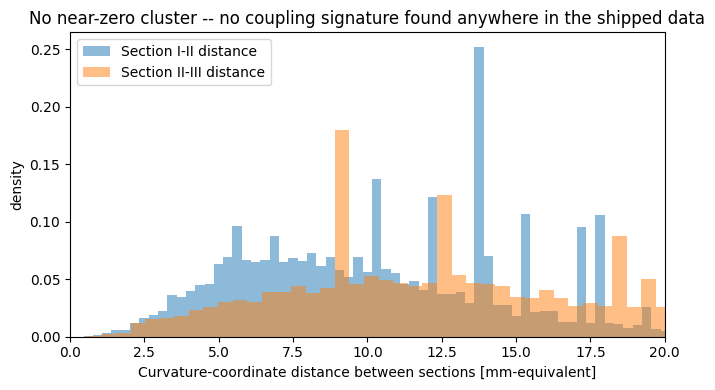


Regime I (all matched, config==0):        0 (0.0%)
Regime II (I&II matched only, config==1): 2 (0.0%)
Regime III (fully independent):           9998 (100.0%)


In [1]:

import numpy as np
import matplotlib.pyplot as plt

d = np.load("results/S31_sample_regime_counts.npz")
d12, d23, d13 = d["d12"], d["d23"], d["d13"]
self_check_gap = float(d["self_check_gap"])

print(f"Self-check (kinematics() vs. SamplingSolver on a synthetic coupled pair): "
      f"max diff {self_check_gap:.2e} -- confirms the detection method itself is exact "
      f"(machine-precision agreement), not the source of what follows.")

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(d12, bins=100, alpha=0.5, label="Section I-II distance", density=True)
ax.hist(d23, bins=100, alpha=0.5, label="Section II-III distance", density=True)
ax.set_xlim(0, 20)
ax.set_xlabel("Curvature-coordinate distance between sections [mm-equivalent]")
ax.set_ylabel("density")
ax.legend()
ax.set_title("No near-zero cluster -- no coupling signature found anywhere in the shipped data")
plt.tight_layout()
plt.savefig("results/s31_bimodality_check.pdf")
plt.show()

print(f"\nRegime I (all matched, config==0):        {d['all_match'].sum()} ({100*d['all_match'].mean():.1f}%)")
print(f"Regime II (I&II matched only, config==1): {d['two_match_12_only'].sum()} ({100*d['two_match_12_only'].mean():.1f}%)")
print(f"Regime III (fully independent):           {d['independent'].sum()} ({100*d['independent'].mean():.1f}%)")


## Finding, not a clean answer to S31

The self-check above confirms the detection method is exact (machine-epsilon
agreement on a synthetic test case), and the tolerance used (0.5, in
curvature-coordinate units) is far looser than mechanical/encoder precision
could ever violate for a genuinely coupled sample (encoder tolerance is
~0.09mm-equivalent). Despite that, **essentially none of the 10,000 shipped
samples show any matched-section signature** — median inter-section distance
is 10-14 units, with no near-zero cluster at all in the histogram above.

This means the shipped MULTI dataset does not show the trace that
`MULTI_data_acquire.py`'s current `config==0/1/2` coupling scheme should
leave if it were actually used to generate this data. The most likely
explanation is that this script is not the exact version that produced the
shipped 10,000 samples (e.g. an earlier or different acquisition script,
possibly fully-independent sampling throughout, was used instead). **This
needs confirmation from whoever ran the original acquisition sessions before
S31 can be answered** — reporting regime counts from this script as fact
would not be honest given this contradiction.